<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 08 - Self-Supervised and Contrastive Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Self-Supervised and Contrastive Learning

Labels are expensive; raw data is cheap. An insurer stores millions of photos of damaged cars, but only a few thousand were ever annotated by an expert with the damaged part and the severity. A hospital has years of X-rays and a handful of radiologist reports in a structured form. **Self-supervised learning** (SSL) trains a network on the unlabelled data with a task whose labels come from the data itself, and then uses the few labels only at the end, to read the answer out of the learned features.

You have already used it: word2vec predicts a word from its neighbours, BERT fills in masked tokens, GPT predicts the next token, an autoencoder reconstructs its input. In this lab we build the method that made self-supervision work for images, **contrastive learning** (SimCLR): two random augmentations of the same image must get similar embeddings, and different images must not. We train it on 60,000 MNIST digits **without their labels**, then measure what 10, 100 or 1,000 labels per class can do with the learned features, compared with a network trained from scratch on the same labels.

**Contents**

1. Self-supervision: the data provide the labels
2. The contrastive loss (InfoNCE / NT-Xent) by hand
3. Augmentations: two views of every image
4. SimCLR on 60,000 unlabelled digits
5. Linear probe and kNN on frozen features
6. The few-label curve
7. Geometry of the embedding: alignment, uniformity, t-SNE
8. Collapse without negatives, and the SimSiam fix
9. Ablation: the augmentations decide what is learned
10. Summary and exercises

This lab goes with the slides *Extra 8 · Self-supervised and contrastive learning* and uses the same notation. It assumes CNNs, the PyTorch training loop, softmax and cross-entropy, embeddings and cosine similarity (Neural networks 1–6). Everything runs on a CPU: about 6.5 minutes with 4 threads (a free Colab CPU has 2 threads: expect 10 to 12 minutes); a GPU is not needed.

**Notation**

| Symbol | Meaning |
|---|---|
| $x$; $t, t' \sim \mathcal{T}$; $\tilde x = t(x)$ | an unlabelled image; two random augmentations; a **view** of the image |
| $f$, $\mathbf{h} = f(\tilde x) \in \mathbb{R}^{64}$ | encoder (a small CNN) and the **representation** we keep |
| $g$, $\mathbf{z} = g(\mathbf{h}) \in \mathbb{R}^{64}$ | projection head and the **projection** the loss sees (thrown away after training) |
| $N$; $2N$ | images in a batch; views in a batch (two per image) |
| $p(i)$ | index of the **positive** of view $i$: the other view of the same image |
| $s_{ij} = \mathbf{z}_i^\top\mathbf{z}_j / (\lVert\mathbf{z}_i\rVert\,\lVert\mathbf{z}_j\rVert)$ | cosine similarity |
| $\tau$ | temperature |
| $\ell_i$, $\mathcal{L}$ | loss of view $i$; NT-Xent (InfoNCE) loss of the batch |
| $\mathcal{L}_{\text{align}}$, $\mathcal{L}_{\text{unif}}$ | alignment and uniformity of the normalised projections |
| $\operatorname{sg}(\cdot)$ | stop-gradient: a constant for backpropagation |
| $m$ | labelled examples **per class** in the few-label experiments |

In [1]:
import time, math, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| torchvision", torchvision.__version__, "| threads", torch.get_num_threads())
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | torchvision 0.27.0+cu130 | threads 4


## 1. Self-supervision: the data provide the labels

A **pretext task** is a prediction problem whose targets are computed from the input itself, so it needs no human labels. We do not care about the pretext task; we care about the features the network must learn to solve it. The course already contains four:

| Method | Input | Hidden part = target | What the features learn |
|---|---|---|---|
| word2vec (skip-gram) | a word | its neighbouring words | words used in the same contexts get close vectors |
| BERT | a sentence with 15 % of tokens masked | the masked tokens | bidirectional context |
| GPT | the first $t$ tokens | token $t+1$ | everything needed to continue a text |
| autoencoder | an image | the same image, through a bottleneck | a compressed code |

For images, early pretext tasks hid something and asked the network to recover it: the **rotation** applied to the image (0°, 90°, 180° or 270°), the order of shuffled **jigsaw** tiles, the **colours** of a greyscale photo, a masked region (**inpainting**). They work, but the features specialise in the pretext: to tell the rotation of a digit it is enough to find where its "top" is.

**The protocol** used throughout the field, and in this lab:

1. **Pretrain** an encoder $f$ on unlabelled data with a self-supervised loss.
2. **Freeze** it and evaluate the features with few labels: a **linear probe** (logistic regression on $\mathbf{h} = f(x)$) or a **$k$-nearest-neighbour** classifier. Or **fine-tune** the whole network on the labelled examples.
3. Compare with the same network trained from scratch on the same labels.

We use MNIST: 60,000 training digits that we treat as **unlabelled** (their labels are used only to evaluate), and the 10,000 test digits. Images are shown dark on white.

unlabelled pool: (60000, 1, 28, 28)   test: (10000, 1, 28, 28)   pixel range [0, 1]
mean pixel: 0.1307 (expected 0.1307)


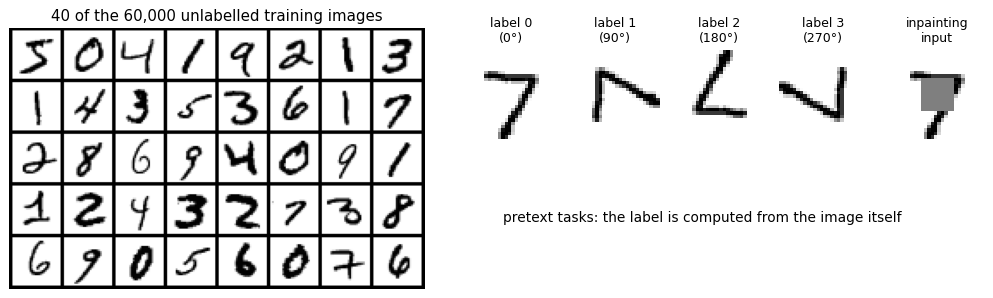

In [2]:
root = "data"
train_set = torchvision.datasets.MNIST(root, train=True, download=True)
test_set = torchvision.datasets.MNIST(root, train=False, download=True)
X_unlab = train_set.data.float().div(255).unsqueeze(1)      # (60000, 1, 28, 28) in [0, 1]
y_train = train_set.targets                                  # hidden during pretraining
X_test = test_set.data.float().div(255).unsqueeze(1)
y_test = test_set.targets
MEAN, STD = 0.1307, 0.3081                                   # MNIST pixel statistics, for the encoder input
n_unlab = len(X_unlab)
print(f"unlabelled pool: {tuple(X_unlab.shape)}   test: {tuple(X_test.shape)}   pixel range [{X_unlab.min():.0f}, {X_unlab.max():.0f}]")
print("mean pixel:", round(X_unlab.mean().item(), 4), "(expected 0.1307)")

# a pretext task needs no labels: rotations of one image, labelled 0, 1, 2, 3 by construction
x0 = X_test[0, 0]
rots = [torch.rot90(x0, k, dims=(0, 1)) for k in range(4)]
masked = x0.clone(); masked[9:19, 9:19] = 0.5               # inpainting: hide the centre, predict it

fig = plt.figure(figsize=(11, 4))
ax = fig.add_axes([0.0, 0.05, 0.42, 0.85])
grid = torchvision.utils.make_grid(X_unlab[:40], nrow=8, padding=2, pad_value=1)[0]
ax.imshow(grid, cmap="gray_r"); ax.set_title("40 of the 60,000 unlabelled training images"); ax.axis("off")
for k in range(4):
    a = fig.add_axes([0.46 + k * 0.105, 0.45, 0.095, 0.4]); a.imshow(rots[k], cmap="gray_r"); a.axis("off")
    a.set_title(f"label {k}\n({90 * k}°)", fontsize=10)
a = fig.add_axes([0.46 + 4 * 0.105 + 0.01, 0.45, 0.095, 0.4]); a.imshow(masked, cmap="gray_r", vmin=0, vmax=1); a.axis("off")
a.set_title("inpainting\ninput", fontsize=10)
fig.text(0.70, 0.3, "pretext tasks: the label is computed from the image itself", ha="center", fontsize=11)
plt.show()

**Things to notice.**
- Nothing in the left panel tells us which digit is which, and we will not use that information until section 5.
- The rotation labels on the right were produced by a line of code, not by an annotator: that is the whole idea of a pretext task. A network that learns to predict them must find the orientation of the strokes, which is useful, but it could also latch onto low-level cues (for natural images: the sky is at the top, the ground at the bottom).
- Contrastive learning replaces "predict the transformation" by "ignore the transformation": the features must be the **same** for two transformed copies of an image. That is section 2.

## 2. The contrastive loss (InfoNCE / NT-Xent) by hand

Take a batch of $N$ images and augment each one twice: $2N$ views. View $i$ has exactly one **positive**, $p(i)$, the other view of the same image, and $2N-2$ **negatives**, the views of the other images. The encoder and the head map every view to a projection $\mathbf{z}_i$, and we compare projections with the cosine similarity $s_{ij}$.

For view $i$ the loss is a softmax over its $2N-1$ candidates (all views but itself):

$$
\ell_i = -\log\frac{\exp(s_{i,p(i)}/\tau)}{\sum_{k \ne i}\exp(s_{ik}/\tau)},
\qquad
\mathcal{L} = \frac{1}{2N}\sum_{i=1}^{2N}\ell_i .
$$

This is the **NT-Xent** loss of SimCLR (normalised temperature-scaled cross-entropy), a form of the **InfoNCE** loss of CPC (van den Oord et al., 2018).

**It is a cross-entropy.** Read row $i$ of the matrix $\mathbf{S}/\tau$ (with the diagonal removed) as the logits of a $(2N-1)$-way classifier whose correct class is $p(i)$. Then $\ell_i$ is exactly the cross-entropy of that classifier, and $\mathcal{L}$ is `F.cross_entropy(S / tau, targets)` with the diagonal masked to $-\infty$. Each view must **recognise its partner among the batch**.

**Gradient.** With $P_{ik} = \operatorname{softmax}_k(s_{ik}/\tau)$,
$$
\frac{\partial \ell_i}{\partial s_{ik}} = \frac{1}{\tau}\big(P_{ik} - [k = p(i)]\big).
$$
*Proof.* $\ell_i = -s_{i,p(i)}/\tau + \log\sum_{k\ne i} e^{s_{ik}/\tau}$. The derivative of the first term is $-1/\tau$ for $k = p(i)$ and 0 otherwise; the derivative of the log-sum-exp is $e^{s_{ik}/\tau}/(\tau\sum_{k'} e^{s_{ik'}/\tau}) = P_{ik}/\tau$. $\blacksquare$

So gradient descent **raises** the similarity to the positive with weight $(1 - P_{i,p(i)})/\tau$ and **lowers** the similarity to each negative with weight $P_{ik}/\tau$: negatives that already look like the anchor (hard negatives) are pushed hardest.

We check all of this on a toy batch of $N = 4$ images with 3-D projections (the batch of the slides), $\tau = 0.5$. Views are ordered $1a, 2a, 3a, 4a, 1b, 2b, 3b, 4b$, so $p(i) = i + N$ for the first half and $i - N$ for the second.

In [3]:
za = torch.tensor([[1.0, 0.2, 0.0], [0.1, 1.0, 0.1], [0.0, 0.1, 1.0], [0.7, 0.7, 0.0]])   # view a of images 1-4
zb = torch.tensor([[0.9, 0.4, 0.1], [0.2, 0.9, 0.0], [0.1, 0.3, 0.9], [0.4, 0.8, 0.3]])   # view b of images 1-4
tau, N = 0.5, 4
names = ["1a", "2a", "3a", "4a", "1b", "2b", "3b", "4b"]
pos = [(i + N) % (2 * N) for i in range(2 * N)]                                          # p(i)

Zn = F.normalize(torch.cat([za, zb]), dim=1)
S = Zn @ Zn.T                                                                          # cosine similarities
print("S (rows and columns 1a ... 4b):\n", S.numpy())

# 1) the definition, one view at a time
losses = []
for i in range(2 * N):
    num = torch.exp(S[i, pos[i]] / tau)
    den = sum(torch.exp(S[i, k] / tau) for k in range(2 * N) if k != i)
    losses.append(-torch.log(num / den))
losses = torch.stack(losses)
print("ℓ_i by the definition:", losses.numpy().round(3), "  mean L =", round(losses.mean().item(), 4))

# 2) the same loss as a cross-entropy over the batch
def nt_xent(z1, z2, tau=0.5, return_acc=False):
    # NT-Xent loss of a batch: z1[i] and z2[i] are the projections of the two views of image i
    n = z1.shape[0]
    z = F.normalize(torch.cat([z1, z2]), dim=1)
    logits = z @ z.T / tau
    logits = logits.masked_fill(torch.eye(2 * n, dtype=torch.bool, device=z.device), float("-inf"))   # drop k = i
    targets = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)]).to(z.device)                 # p(i)
    loss = F.cross_entropy(logits, targets)
    if return_acc:                                          # is the positive the most similar view?
        return loss, (logits.argmax(1) == targets).float().mean().item()
    return loss

L_ce = nt_xent(za, zb, tau)
print("F.cross_entropy version:", round(L_ce.item(), 4), "  chance level log(2N - 1) = log 7 =", round(math.log(7), 4))
assert torch.allclose(L_ce, losses.mean(), atol=1e-6)

# 3) the gradient formula, checked with autograd
S_leaf = S.clone().requires_grad_(True)
masked_logits = (S_leaf / tau).masked_fill(torch.eye(2 * N, dtype=torch.bool), float("-inf"))
F.cross_entropy(masked_logits, torch.tensor(pos), reduction="sum").backward()      # sum of the ℓ_i
P = torch.softmax(masked_logits.detach(), dim=1)
assert torch.allclose(S_leaf.grad, (P - F.one_hot(torch.tensor(pos), 2 * N)) / tau, atol=1e-6)
print("∂ℓ_i/∂s_ik = (P_ik - [k = p(i)]) / τ   checked with autograd")
print("row 1a: P =", P[0].numpy().round(3), " -> positive 1b gets", round(P[0, 4].item(), 3),
      "and the hard negative 4a", round(P[0, 3].item(), 3))

S (rows and columns 1a ... 4b):
 [[1.    0.291 0.02  0.832 0.971 0.404 0.164 0.582]
 [0.291 1.    0.197 0.77  0.5   0.988 0.415 0.913]
 [0.02  0.197 1.    0.07  0.141 0.097 0.97  0.401]
 [0.832 0.77  0.07  1.    0.929 0.844 0.296 0.899]
 [0.971 0.5   0.141 0.929 1.    0.592 0.318 0.76 ]
 [0.404 0.988 0.097 0.844 0.592 1.    0.33  0.92 ]
 [0.164 0.415 0.97  0.296 0.318 0.33  1.    0.611]
 [0.582 0.913 0.401 0.899 0.76  0.92  0.611 1.   ]]
ℓ_i by the definition: [1.146 1.296 0.794 1.627 1.36  1.341 1.039 1.665]   mean L = 1.2836
F.cross_entropy version: 1.2836   chance level log(2N - 1) = log 7 = 1.9459
∂ℓ_i/∂s_ik = (P_ik - [k = p(i)]) / τ   checked with autograd
row 1a: P = [0.    0.082 0.047 0.241 0.318 0.102 0.063 0.146]  -> positive 1b gets 0.318 and the hard negative 4a 0.241


**The temperature.** Dividing by $\tau$ before the softmax scales all the gaps between similarities. A small $\tau$ makes the softmax peaky: almost all the weight goes to the most similar candidates, so the loss concentrates on the **hard negatives**. A large $\tau$ makes it flat: every negative is pushed about equally, and the loss cannot get far below its chance value. The ratio of the pushes on two negatives $k$ and $k'$ is $P_{ik}/P_{ik'} = e^{(s_{ik} - s_{ik'})/\tau}$.

τ = 0.05:  ℓ_1a = 0.061   p(1b) = 0.941   p(4a) = 0.059   push on 4a / push on 3a = 11418220.0  (= exp((0.832 - 0.020) / τ))
τ = 0.10:  ℓ_1a = 0.243   p(1b) = 0.784   p(4a) = 0.196   push on 4a / push on 3a =    3379.1  (= exp((0.832 - 0.020) / τ))
τ = 0.20:  ℓ_1a = 0.566   p(1b) = 0.568   p(4a) = 0.284   push on 4a / push on 3a =      58.1  (= exp((0.832 - 0.020) / τ))
τ = 0.50:  ℓ_1a = 1.146   p(1b) = 0.318   p(4a) = 0.241   push on 4a / push on 3a =       5.1  (= exp((0.832 - 0.020) / τ))
τ = 1.00:  ℓ_1a = 1.494   p(1b) = 0.224   p(4a) = 0.195   push on 4a / push on 3a =       2.3  (= exp((0.832 - 0.020) / τ))
τ = 2.00:  ℓ_1a = 1.707   p(1b) = 0.181   p(4a) = 0.169   push on 4a / push on 3a =       1.5  (= exp((0.832 - 0.020) / τ))


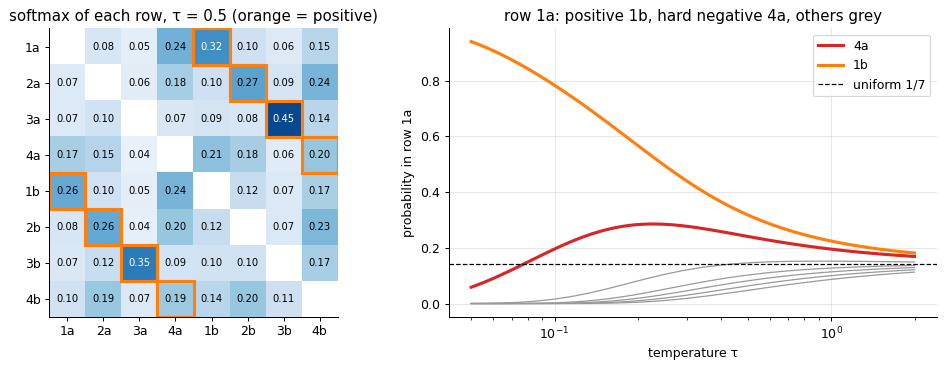

In [4]:
taus = np.geomspace(0.05, 2, 60)
row = S[0].numpy()
def row_softmax(row, i, tau):
    e = np.exp(row / tau); e[i] = 0
    return e / e.sum()
probs = np.array([row_softmax(row, 0, t) for t in taus])               # (60, 8)
for t in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]:
    p = row_softmax(row, 0, t)
    print(f"τ = {t:4.2f}:  ℓ_1a = {-np.log(p[4]):.3f}   p(1b) = {p[4]:.3f}   p(4a) = {p[3]:.3f}   "
          f"push on 4a / push on 3a = {p[3] / p[2]:9.1f}  (= exp((0.832 - 0.020) / τ))")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.15]})
Pm = P.numpy().copy(); Pm[np.eye(8, dtype=bool)] = np.nan
im = axes[0].imshow(Pm, cmap="Blues", vmin=0, vmax=0.5)
for i in range(8):
    for k in range(8):
        if i != k:
            axes[0].text(k, i, f"{Pm[i, k]:.2f}", ha="center", va="center", fontsize=8, color="white" if Pm[i, k] > 0.3 else "black")
    axes[0].add_patch(plt.Rectangle((pos[i] - 0.5, i - 0.5), 1, 1, fill=False, ec="tab:orange", lw=2.5))
axes[0].set_xticks(range(8), names); axes[0].set_yticks(range(8), names); axes[0].grid(False)
axes[0].set_title(f"softmax of each row, τ = {tau} (orange = positive)")
cols = ["C1" if k == 4 else ("C3" if k == 3 else "0.6") for k in range(8)]
for k in range(1, 8):
    axes[1].plot(taus, probs[:, k], color=cols[k], lw=2.5 if k in (3, 4) else 1, label=names[k] if k in (3, 4) else None)
axes[1].axhline(1 / 7, ls="--", color="k", lw=1, label="uniform 1/7")
axes[1].set_xscale("log"); axes[1].set_xlabel("temperature τ"); axes[1].set_ylabel("probability in row 1a")
axes[1].set_title("row 1a: positive 1b, hard negative 4a, others grey"); axes[1].legend()
plt.tight_layout(); plt.show()

**What just happened?**
- The three computations agree: the loop over the views, the cross-entropy over the masked similarity matrix, and autograd's gradient. The mean loss is 1.2836: below the chance level $\log 7 = 1.946$, because in most rows the positive is already among the most similar candidates, but far from 0.
- Row 1a gives its positive 1b only 0.318 of the probability. Image 4, with $\mathbf{z} = (0.7, 0.7, 0)$, resembles image 1 ($s_{1a,4a} = 0.832$) and takes 0.241: a **hard negative**. The gradient pushes it 5.1 times harder than the easy negative 3a ($s = 0.020$).
- The temperature changes the picture completely. At $\tau = 2$ the softmax of row 1a is almost flat ($p(1b) = 0.181$, against $1/7 = 0.143$) and $\ell_{1a} = 1.707$. At $\tau = 0.1$, $p(1b) = 0.784$ and the push on 4a is 3,379 times the push on 3a. At $\tau = 0.05$ only the positive and the hardest negative matter ($\ell_{1a} = 0.061$). A small $\tau$ focuses the loss on hard negatives, including **false negatives** (other images of the same class); a large one treats all negatives alike. We use $\tau = 0.5$, a common value for small batches.

## 3. Augmentations: two views of every image

The positives are made by augmentation, so **the augmentations define what the representation ignores**. Whatever $t$ changes, the loss asks $f$ to be invariant to. SimCLR (Chen et al., 2020) found that the composition of a **random resized crop** and a strong **colour distortion** matters most: crop alone lets the network match two crops by their colour histogram, a shortcut that solves the pretext task without looking at shapes.

Our $\mathcal{T}$ for digits, applied independently to every image of the batch:

1. **Random resized crop + rotation**: keep a random rectangle covering 50 to 100 % of the image (aspect ratio between 3/4 and 4/3), rotate by up to ±15°, resize back to 28 × 28. One affine warp does all three (`affine_grid` + `grid_sample`), batched. No horizontal flip: a mirrored digit is often not a digit.
2. **Brightness and contrast jitter** (probability 0.8): $x \leftarrow c\,(x - \bar x) + \bar x + b$ with $c \in [0.6, 1.4]$, $b \in [-0.25, 0.25]$; the greyscale version of colour jitter.
3. **Random erasing** (probability 0.25): set a rectangle of 4 to 12 pixels per side to 0.

All the random numbers come from one `torch.Generator`, so every run sees the same views.

views: (8, 1, 28, 28)  range 0.0 to 1.0   the two views differ: True
augmenting a batch of 256 images: 1.3 ms


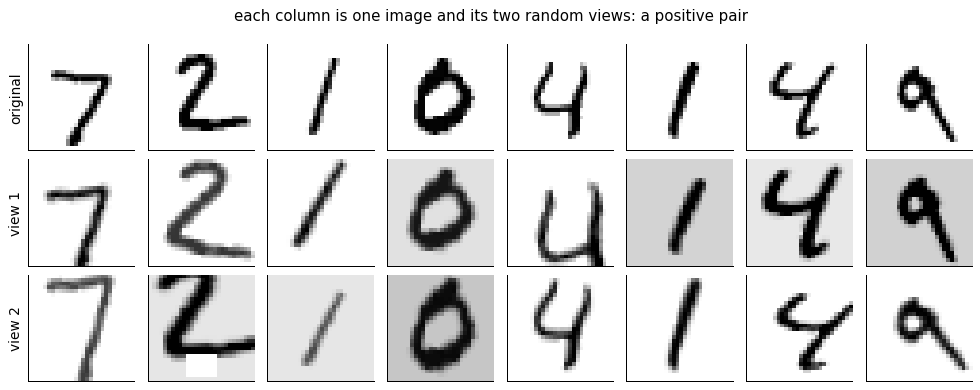

In [5]:
def augment(x, g, geometric=True, jitter=True, erase=True, steps=False, area=0.5, deg=15):
    # Random view of each image of the batch x (B, 1, 28, 28). Returns the views, or the intermediate stages if steps=True.
    # area: smallest crop area (fraction of the image); deg: largest rotation in degrees
    B = x.shape[0]
    r = lambda *s: torch.rand(*s, generator=g)
    out = [x]
    if geometric:                                                     # crop (area 50-100 %) + rotation (±15°) + resize
        area, log_ar = area + (1 - area) * r(B), (r(B) * 2 - 1) * math.log(4 / 3)
        w = torch.sqrt(area * torch.exp(log_ar)).clamp(max=1)         # crop width and height, as fractions of the image
        h = torch.sqrt(area / torch.exp(log_ar)).clamp(max=1)
        cx, cy = (r(B) * 2 - 1) * (1 - w), (r(B) * 2 - 1) * (1 - h)   # crop centre, inside the image
        ang = (r(B) * 2 - 1) * math.radians(deg)
        cos, sin = torch.cos(ang), torch.sin(ang)
        theta = torch.stack([torch.stack([w * cos, -h * sin, cx], 1),
                             torch.stack([w * sin, h * cos, cy], 1)], 1)   # output coords -> input coords
        grid = F.affine_grid(theta, list(x.shape), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False, padding_mode="zeros")
    out.append(x)
    if jitter:                                                        # brightness / contrast, probability 0.8
        on = (r(B, 1, 1, 1) < 0.8).float()
        c, b = 0.6 + 0.8 * r(B, 1, 1, 1), (r(B, 1, 1, 1) * 2 - 1) * 0.25
        m = x.mean((2, 3), keepdim=True)
        x = (on * ((x - m) * c + m + b) + (1 - on) * x).clamp(0, 1)
    out.append(x)
    if erase:                                                         # random erasing, probability 0.25
        eh, ew = (4 + r(B) * 8).long(), (4 + r(B) * 8).long()
        ey, ex = (r(B) * (28 - eh)).long(), (r(B) * (28 - ew)).long()
        yy, xx = torch.arange(28).view(1, 28, 1), torch.arange(28).view(1, 1, 28)
        box = ((yy >= ey.view(-1, 1, 1)) & (yy < (ey + eh).view(-1, 1, 1)) &
               (xx >= ex.view(-1, 1, 1)) & (xx < (ex + ew).view(-1, 1, 1)) & (r(B).view(-1, 1, 1) < 0.25))
        x = x.masked_fill(box.unsqueeze(1), 0.0)
    out.append(x.clamp(0, 1))
    return out if steps else out[-1]

g_demo = torch.Generator().manual_seed(1)
x8 = X_test[:8]
t0 = time.time(); v1, v2 = augment(x8, g_demo), augment(x8, g_demo)
print("views:", tuple(v1.shape), " range", round(v1.min().item(), 2), "to", round(v1.max().item(), 2),
      "  the two views differ:", not torch.equal(v1, v2))
gb = torch.Generator().manual_seed(0); xb = X_unlab[:256]
t0 = time.time(); _ = augment(xb, gb); print(f"augmenting a batch of 256 images: {1000 * (time.time() - t0):.1f} ms")

fig, axes = plt.subplots(3, 8, figsize=(11, 4.4))
for j in range(8):
    for r_, (img, lab) in enumerate([(x8, "original"), (v1, "view 1"), (v2, "view 2")]):
        axes[r_, j].imshow(img[j, 0], cmap="gray_r", vmin=0, vmax=1); axes[r_, j].set_xticks([]); axes[r_, j].set_yticks([])
        if j == 0: axes[r_, j].set_ylabel(lab, fontsize=11)
fig.suptitle("each column is one image and its two random views: a positive pair", y=0.98)
plt.tight_layout(); plt.show()

**Things to notice.** The two views of a digit can differ a lot in position, size, angle, stroke darkness and even miss a piece, yet a person reads the same digit in both. That is what we ask of $f$: the same $\mathbf{h}$ for both views, and different $\mathbf{h}$ for different digits **of any class**, since the loss does not know the classes. Two different images of the digit 1 are negatives of each other in the batch; with 10 classes and $N = 256$ about a tenth of the negatives of each view are such "false negatives", and the method works anyway.

## 4. SimCLR on 60,000 unlabelled digits

The model has two parts.

- **Encoder** $f$: three convolutional blocks with 16, 32 and 64 channels (3 × 3 convolutions, batch normalisation, ReLU, max pooling), then global average pooling. Output: the representation $\mathbf{h} \in \mathbb{R}^{64}$. This is the network we keep.
- **Projection head** $g$: a small MLP $64 \to 64 \to 64$ (Linear, BatchNorm, ReLU, Linear). Output: $\mathbf{z}$, the only thing the loss sees. It is thrown away after pretraining; section 5 shows why.

Training: batches of $N = 256$ images (512 views), $\tau = 0.5$, Adam with learning rate $10^{-3}$, 1,200 steps (about 5 passes over the unlabelled pool). We log the loss and the **contrastive accuracy**, the fraction of views whose most similar view in the batch is their positive (chance: 1/511). Every few hundred steps we also measure a **kNN monitor**, the accuracy of a $k$-nearest-neighbour classifier on frozen $\mathbf{h}$ (5,000 labelled training digits as memory, 2,000 test digits as queries). The monitor is the only place where labels appear, and they never reach the gradient.

**kNN on features.** We centre the features (subtract the mean of the memory set), normalise them to unit length and take the $k = 20$ most cosine-similar memory items; each votes for its class with weight $e^{s/0.1}$. Centring matters because $\mathbf{h}$ comes out of a ReLU and an average: all its entries are positive, so all raw cosines are high and dominated by the common mean direction.

In [6]:
class Encoder(nn.Module):
    # f: three conv blocks (16, 32, 64 channels) and global average pooling -> h in R^64
    def __init__(self, widths=(16, 32, 64)):
        super().__init__()
        layers, c_in = [], 1
        for i, c in enumerate(widths):
            layers += [nn.Conv2d(c_in, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU()]
            layers += [nn.MaxPool2d(2)] if i < len(widths) - 1 else [nn.AdaptiveAvgPool2d(1), nn.Flatten()]
            c_in = c
        self.net = nn.Sequential(*layers)
        self.dim = widths[-1]

    def forward(self, x):
        return self.net((x - MEAN) / STD)


def projection_head(d=64, d_out=64):
    # g: Linear - BatchNorm - ReLU - Linear
    return nn.Sequential(nn.Linear(d, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Linear(d, d_out))


@torch.no_grad()
def features(model, X, bs=2000):
    # Frozen features of X (eval mode: batch norm uses its running statistics).
    model.eval()
    return torch.cat([model(X[i:i + bs].to(device)).cpu() for i in range(0, len(X), bs)])


def knn_accuracy(F_mem, y_mem, F_query, y_query, k=20, T=0.1):
    # Weighted kNN on centred, L2-normalised features (cosine similarity).
    mu = F_mem.mean(0)
    A, B = F.normalize(F_mem - mu, dim=1), F.normalize(F_query - mu, dim=1)
    k = min(k, len(A)); correct = 0
    for i in range(0, len(B), 1000):
        s, idx = (B[i:i + 1000] @ A.T).topk(k, dim=1)
        votes = torch.zeros(len(s), 10).scatter_add_(1, y_mem[idx], (s / T).exp())
        correct += (votes.argmax(1) == y_query[i:i + 1000]).sum().item()
    return correct / len(B)


MON_MEM, MON_Q = slice(0, 5000), slice(0, 2000)                       # the kNN monitor
def knn_monitor(enc):
    return knn_accuracy(features(enc, X_unlab[MON_MEM]), y_train[MON_MEM], features(enc, X_test[MON_Q]), y_test[MON_Q])

def zstd(z):
    # std over the batch of the L2-normalised projections, averaged over dimensions (1/sqrt(d) if spread, 0 if collapsed)
    return F.normalize(z.detach(), dim=1).std(0).mean().item()

enc_tmp, head_tmp = Encoder(), projection_head()
n_f = sum(p.numel() for p in enc_tmp.parameters()); n_g = sum(p.numel() for p in head_tmp.parameters())
print(f"encoder f: {n_f:,} parameters   head g: {n_g:,} parameters")
print("h shape:", tuple(enc_tmp(X_unlab[:2]).shape), "  z shape:", tuple(head_tmp(enc_tmp(X_unlab[:2])).shape))

encoder f: 23,520 parameters   head g: 8,448 parameters
h shape: (2, 64)   z shape: (2, 64)


In [7]:
def train_simclr(steps, tau=0.5, batch=256, lr=1e-3, seed=0, aug=None, log_every=50, knn_at=(), snapshot_at=None):
    # SimCLR: returns the encoder, the head, the training log and (optionally) a copy of the encoder at step snapshot_at.
    aug = aug or {}
    torch.manual_seed(seed); g = torch.Generator().manual_seed(seed)
    enc, head = Encoder().to(device), projection_head().to(device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(head.parameters()), lr=lr)
    log = {"step": [], "loss": [], "acc": [], "zstd": [], "knn_step": [], "knn": []}
    run, snap = [], None
    for step in range(steps + 1):
        if step in knn_at:
            log["knn_step"].append(step); log["knn"].append(knn_monitor(enc))
        if step == snapshot_at:
            snap = copy.deepcopy(enc)
        if step == steps:
            break
        enc.train(); head.train()
        x = X_unlab[torch.randint(0, n_unlab, (batch,), generator=g)]
        v1, v2 = augment(x, g, **aug).to(device), augment(x, g, **aug).to(device)
        z1, z2 = head(enc(v1)), head(enc(v2))
        loss, acc = nt_xent(z1, z2, tau, return_acc=True)
        opt.zero_grad(); loss.backward(); opt.step()
        run.append((loss.item(), acc, zstd(z1)))
        if (step + 1) % log_every == 0:
            m = np.mean(run, axis=0); run = []
            log["step"].append(step + 1); log["loss"].append(m[0]); log["acc"].append(m[1]); log["zstd"].append(m[2])
    return enc, head, log, snap

t0 = time.time()
torch.manual_seed(0); enc_rand = Encoder().to(device)   # the untrained network: same seed, so the same start as the SimCLR run
enc_ssl, head_ssl, log_ssl, enc_300 = train_simclr(1200, knn_at=(0, 100, 300, 600, 900, 1200), snapshot_at=300)
t_ssl = time.time() - t0
for s_, l_, a_ in zip(log_ssl["step"][::4], log_ssl["loss"][::4], log_ssl["acc"][::4]):
    print(f"step {s_:5d}   loss {l_:.3f}   contrastive accuracy {a_:.3f}")
print(f"final: loss {log_ssl['loss'][-1]:.3f} (chance log 511 = {math.log(511):.3f}), contrastive accuracy {log_ssl['acc'][-1]:.3f} (chance {1/511:.4f})")
print("kNN monitor:", dict(zip(log_ssl["knn_step"], np.round(log_ssl["knn"], 4))))
print(f"pretraining time: {t_ssl:.0f} s")

step    50   loss 5.209   contrastive accuracy 0.158
step   250   loss 4.734   contrastive accuracy 0.437
step   450   loss 4.665   contrastive accuracy 0.491
step   650   loss 4.633   contrastive accuracy 0.532
step   850   loss 4.610   contrastive accuracy 0.559
step  1050   loss 4.591   contrastive accuracy 0.576
final: loss 4.578 (chance log 511 = 6.236), contrastive accuracy 0.581 (chance 0.0020)
kNN monitor: {0: np.float64(0.7105), 100: np.float64(0.857), 300: np.float64(0.885), 600: np.float64(0.8965), 900: np.float64(0.9105), 1200: np.float64(0.9125)}
pretraining time: 84 s


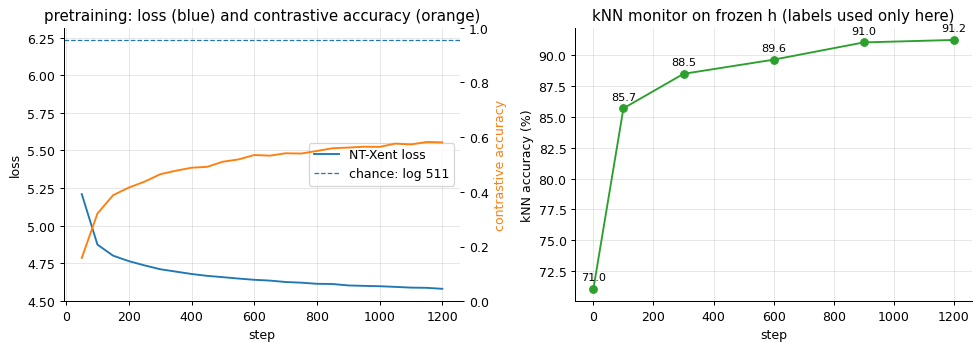

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log_ssl["step"], log_ssl["loss"], color="C0", label="NT-Xent loss")
axes[0].axhline(math.log(511), color="C0", ls="--", lw=1, label="chance: log 511")
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].legend(loc="center right")
ax2 = axes[0].twinx(); ax2.plot(log_ssl["step"], log_ssl["acc"], color="C1"); ax2.set_ylabel("contrastive accuracy", color="C1")
ax2.set_ylim(0, 1); ax2.grid(False); axes[0].set_title("pretraining: loss (blue) and contrastive accuracy (orange)")
axes[1].plot(log_ssl["knn_step"], 100 * np.array(log_ssl["knn"]), "o-", color="C2")
axes[1].set_xlabel("step"); axes[1].set_ylabel("kNN accuracy (%)"); axes[1].set_title("kNN monitor on frozen h (labels used only here)")
for s_, a_ in zip(log_ssl["knn_step"], log_ssl["knn"]):
    axes[1].annotate(f"{100 * a_:.1f}", (s_, 100 * a_), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** In 1,200 steps (about a minute and a half on 4 CPU threads) the loss fell from 5.21 (average of the first 50 steps) to 4.58, against $\log 511 = 6.24$ for random guessing, and the contrastive accuracy rose to 0.58: for 58 % of the views, the most similar of the 511 other views of the batch is their partner. The loss stays far from 0 by design: crops, rotations and erasing make some pairs genuinely ambiguous, and about one negative in ten is another image of the same digit.

The kNN monitor tells the real story. With random weights, a 20-nearest-neighbour classifier on $\mathbf{h}$ gets 71.1 %; after 100 steps 85.7 %, after 300 steps 88.5 %, and 91.3 % at the end. The labels never touched the gradient: the encoder learned to group digits by shape because that is the cheapest way to recognise two views of the same image among 510 others.

## 5. Linear probe and kNN on frozen features

Now the labels come in, but only to **read out** the representation; the encoder is frozen.

- **Linear probe**: standardise the features and fit a multinomial logistic regression, $\hat{\mathbf{y}} = \operatorname{softmax}(\mathbf{W}^\top\mathbf{h} + \mathbf{b})$, minimising the mean cross-entropy plus $\frac{\lambda}{2}\lVert\mathbf{W}\rVert^2$. A linear classifier cannot create new features, so its accuracy measures how **linearly separable** the classes are in $\mathbf{h}$.
- **kNN**: the classifier of section 4, with no training at all. It measures whether **neighbours in feature space share the class**.

We write the probe from scratch (full-batch L-BFGS in PyTorch), check it against scikit-learn's `LogisticRegression` on the same objective, and then compare four representations of every image, all with the 60,000 training labels:

| representation | dimension | trained? |
|---|---|---|
| raw pixels | 784 | no |
| random encoder $\mathbf{h}$ (the same CNN before training) | 64 | no |
| SimCLR $\mathbf{z}$ (after the projection head) | 64 | yes, self-supervised |
| SimCLR $\mathbf{h}$ (before the head) | 64 | yes, self-supervised |

In [9]:
def linear_probe(F_tr, y_tr, F_te, y_te, wd=None, iters=200, return_model=False):
    # Multinomial logistic regression on standardised features, full-batch L-BFGS. wd defaults to 1/n (sklearn's C = 1).
    mu, sd = F_tr.mean(0), F_tr.std(0) + 1e-6
    A, B = (F_tr - mu) / sd, (F_te - mu) / sd
    wd = 1.0 / len(A) if wd is None else wd
    W = torch.zeros(A.shape[1], 10, requires_grad=True); b = torch.zeros(10, requires_grad=True)
    opt = torch.optim.LBFGS([W, b], lr=1, max_iter=iters, history_size=20, line_search_fn="strong_wolfe")
    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(A @ W + b, y_tr) + wd / 2 * (W ** 2).sum()
        loss.backward(); return loss
    opt.step(closure)
    with torch.no_grad():
        pred = (B @ W + b).argmax(1)
    acc = (pred == y_te).float().mean().item()
    return (acc, pred) if return_model else acc

def few_label_indices(m, seed):
    # m labelled examples per class, drawn from the training set
    rs = np.random.RandomState(seed); y = y_train.numpy()
    return torch.tensor(np.concatenate([rs.choice(np.where(y == c)[0], m, replace=False) for c in range(10)]))

t0 = time.time()
H_rand_tr, H_rand_te = features(enc_rand, X_unlab), features(enc_rand, X_test)
H_ssl_tr, H_ssl_te = features(enc_ssl, X_unlab), features(enc_ssl, X_test)
Z_ssl_tr = features(nn.Sequential(enc_ssl, head_ssl), X_unlab); Z_ssl_te = features(nn.Sequential(enc_ssl, head_ssl), X_test)
P_tr, P_te = X_unlab.flatten(1), X_test.flatten(1)

# check the from-scratch probe against scikit-learn (same objective: C = 1/(wd n)), on 100 labels per class
idx = few_label_indices(100, 0)
acc_ours, pred_ours = linear_probe(H_ssl_tr[idx], y_train[idx], H_ssl_te, y_test, wd=1e-3, return_model=True)
mu, sd = H_ssl_tr[idx].mean(0), H_ssl_tr[idx].std(0) + 1e-6
sk = LogisticRegression(C=1.0 / (1e-3 * len(idx)), max_iter=5000).fit(((H_ssl_tr[idx] - mu) / sd).numpy(), y_train[idx].numpy())
pred_sk = sk.predict(((H_ssl_te - mu) / sd).numpy())
agree = (pred_ours.numpy() == pred_sk).mean()
print(f"probe from scratch {acc_ours:.4f}   scikit-learn {np.mean(pred_sk == y_test.numpy()):.4f}   same prediction on {100 * agree:.2f} % of the test digits")
assert agree > 0.99

reps = {"raw pixels": (P_tr, P_te), "random encoder h": (H_rand_tr, H_rand_te),
        "SimCLR z (after head)": (Z_ssl_tr, Z_ssl_te), "SimCLR h (before head)": (H_ssl_tr, H_ssl_te)}
full = {}
for name, (A_, B_) in reps.items():
    full[name] = (linear_probe(A_, y_train, B_, y_test), knn_accuracy(A_, y_train, B_, y_test))
    print(f"{name:24s} dim {A_.shape[1]:4d}   linear probe {100 * full[name][0]:.2f} %   kNN {100 * full[name][1]:.2f} %")
print(f"({time.time() - t0:.0f} s)")
assert full["SimCLR h (before head)"][0] > full["random encoder h"][0]

probe from scratch 0.9638   scikit-learn 0.9642   same prediction on 99.91 % of the test digits


raw pixels               dim  784   linear probe 92.10 %   kNN 96.90 %


random encoder h         dim   64   linear probe 90.46 %   kNN 85.19 %


SimCLR z (after head)    dim   64   linear probe 97.34 %   kNN 96.90 %


SimCLR h (before head)   dim   64   linear probe 98.12 %   kNN 96.52 %
(76 s)


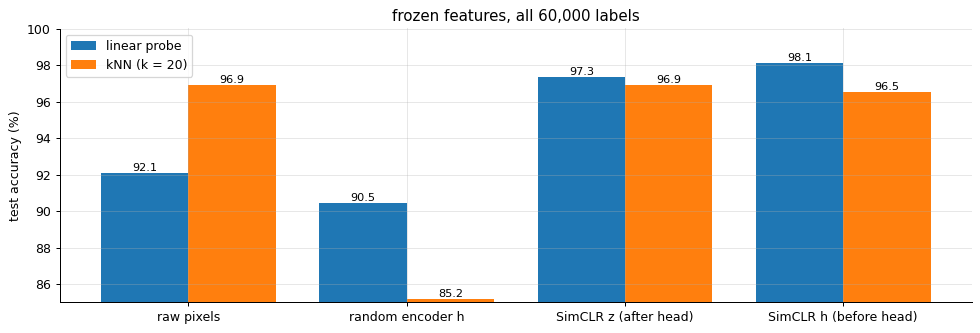

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.8))
names_r = list(full); xs = np.arange(len(names_r))
b1 = ax.bar(xs - 0.2, [100 * full[n][0] for n in names_r], 0.4, label="linear probe", color="C0")
b2 = ax.bar(xs + 0.2, [100 * full[n][1] for n in names_r], 0.4, label="kNN (k = 20)", color="C1")
ax.bar_label(b1, fmt="%.1f", fontsize=9); ax.bar_label(b2, fmt="%.1f", fontsize=9)
ax.set_xticks(xs, names_r); ax.set_ylim(85, 100); ax.set_ylabel("test accuracy (%)")
ax.set_title("frozen features, all 60,000 labels"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**What just happened?**
- The probe written from scratch agrees with scikit-learn: 96.38 % against 96.42 %, with the same prediction on 99.91 % of the test digits (the two optimisers stop at slightly different points).
- **SimCLR $\mathbf{h}$ is the best input for a linear classifier: 98.12 %**, against 92.10 % for the 784 raw pixels and 90.46 % for the same network with random weights. Self-supervised pretraining made the ten digits almost linearly separable in 64 numbers.
- **$\mathbf{h}$ beats $\mathbf{z}$** for the probe: 98.12 % against 97.34 %. The projection head was trained to throw away whatever distinguishes two views of a digit (position, size, stroke darkness), and some of that helps to tell digits apart. This is why SimCLR keeps $\mathbf{h}$ and discards $g$. With kNN the order flips slightly (96.52 % against 96.90 %): $\mathbf{z}$ is the space the loss shaped for cosine similarity.
- kNN on raw pixels is strong on MNIST (96.90 %): the digits are centred and size-normalised, so pixel distances are already meaningful. That is a property of MNIST, not of images in general; on photos, pixel neighbours are useless. The random encoder's kNN, 85.19 %, shows that random features do not preserve these distances.

## 6. The few-label curve

The real question: **how many labels do we need?** We draw $m = 10$, 100 and 1,000 labelled digits per class from the training set (3 random draws for $m = 10$ and 100, one for 1,000) and compare six ways of using them:

1. linear probe on **raw pixels**;
2. linear probe on the **random encoder**;
3. linear probe on **SimCLR** $\mathbf{h}$;
4. **kNN** on SimCLR $\mathbf{h}$ ($k = \min(20, m)$);
5. **supervised from scratch**: the same CNN plus a classifier (batch normalisation, then a linear layer, so that $\mathbf{h}$ is standardised as in the probe), trained on the $m$ labels only with Adam ($10^{-3}$), a milder crop (80–100 % of the area) and ±10° rotations, for 300, 400 and 800 steps ($m$ = 10, 100, 1,000);
6. **fine-tuning SimCLR**: the same, but starting from the pretrained encoder, with a smaller learning rate for it ($3 \times 10^{-4}$) so that the first steps of the new classifier do not wreck the features.

All are tested on the 10,000 test digits.

In [11]:
def train_classifier(idx, init=None, steps=300, lr=1e-3, enc_lr=None, seed=0):
    # CNN + classifier trained on the labelled subset idx; init = a pretrained encoder to fine-tune (or None)
    torch.manual_seed(seed); g = torch.Generator().manual_seed(1000 + seed)
    enc = copy.deepcopy(init) if init is not None else Encoder()
    clf = nn.Sequential(nn.BatchNorm1d(64), nn.Linear(64, 10))          # standardise h, then a linear layer (as the probe)
    enc, clf = enc.to(device), clf.to(device)
    opt = torch.optim.Adam([{"params": enc.parameters(), "lr": enc_lr or lr}, {"params": clf.parameters(), "lr": lr}])
    Xl, yl = X_unlab[idx], y_train[idx]; bs = min(128, len(idx))
    for step in range(steps):
        enc.train(); clf.train()
        b = torch.randint(0, len(idx), (bs,), generator=g)
        x = augment(Xl[b], g, jitter=False, erase=False, area=0.8, deg=10).to(device)   # mild crop + rotation
        loss = F.cross_entropy(clf(enc(x)), yl[b].to(device))
        opt.zero_grad(); loss.backward(); opt.step()
    logits = features(nn.Sequential(enc, clf), X_test)
    return (logits.argmax(1) == y_test).float().mean().item()

t0 = time.time()
M_LIST = [10, 100, 1000]; SEEDS = {10: [0, 1, 2], 100: [0, 1, 2], 1000: [0]}; STEPS = {10: 300, 100: 400, 1000: 800}
methods = ["probe · pixels", "probe · random encoder", "probe · SimCLR", "kNN · SimCLR", "supervised from scratch", "fine-tuned SimCLR"]
res = {mth: {m: [] for m in M_LIST} for mth in methods}
for m in M_LIST:
    for seed in SEEDS[m]:
        idx = few_label_indices(m, seed)
        res["probe · pixels"][m].append(linear_probe(P_tr[idx], y_train[idx], P_te, y_test))
        res["probe · random encoder"][m].append(linear_probe(H_rand_tr[idx], y_train[idx], H_rand_te, y_test))
        res["probe · SimCLR"][m].append(linear_probe(H_ssl_tr[idx], y_train[idx], H_ssl_te, y_test))
        res["kNN · SimCLR"][m].append(knn_accuracy(H_ssl_tr[idx], y_train[idx], H_ssl_te, y_test, k=min(20, m)))
        res["supervised from scratch"][m].append(train_classifier(idx, steps=STEPS[m], seed=seed))
        res["fine-tuned SimCLR"][m].append(train_classifier(idx, init=enc_ssl, enc_lr=3e-4, steps=STEPS[m], seed=seed))
    print(f"m = {m:4d} done ({time.time() - t0:.0f} s)")
print(f"\n{'method':26s}" + "".join(f"   m = {m:<14d}" for m in M_LIST))
for mth in methods:
    print(f"{mth:26s}" + "".join(f"   {100 * np.mean(res[mth][m]):5.1f} ± {100 * np.std(res[mth][m]):3.1f} %   " for m in M_LIST))

m =   10 done (32 s)


m =  100 done (79 s)


m = 1000 done (113 s)

method                       m = 10               m = 100              m = 1000          
probe · pixels                73.2 ± 0.6 %       86.8 ± 0.8 %       89.1 ± 0.0 %   
probe · random encoder        68.5 ± 2.0 %       84.0 ± 0.4 %       89.8 ± 0.0 %   
probe · SimCLR                92.5 ± 1.3 %       96.5 ± 0.2 %       97.8 ± 0.0 %   
kNN · SimCLR                  75.2 ± 1.4 %       89.8 ± 0.6 %       95.0 ± 0.0 %   
supervised from scratch       88.0 ± 1.5 %       95.5 ± 0.6 %       96.5 ± 0.0 %   
fine-tuned SimCLR             92.0 ± 1.3 %       96.5 ± 0.4 %       97.9 ± 0.0 %   


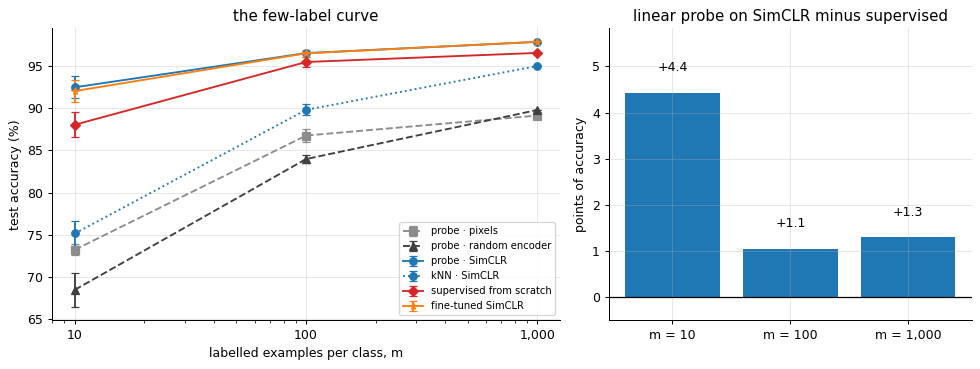

In [12]:
style = {"probe · pixels": ("0.55", "s", "--"), "probe · random encoder": ("0.25", "^", "--"), "probe · SimCLR": ("C0", "o", "-"),
         "kNN · SimCLR": ("C0", "o", ":"), "supervised from scratch": ("C3", "D", "-"), "fine-tuned SimCLR": ("C1", "*", "-")}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})
for mth in methods:
    c, mk, ls = style[mth]
    mean = [100 * np.mean(res[mth][m]) for m in M_LIST]; sd = [100 * np.std(res[mth][m]) for m in M_LIST]
    axes[0].errorbar(M_LIST, mean, yerr=sd, color=c, marker=mk, ls=ls, capsize=3, label=mth)
axes[0].set_xscale("log"); axes[0].set_xticks(M_LIST, ["10", "100", "1,000"])
axes[0].set_xlabel("labelled examples per class, m"); axes[0].set_ylabel("test accuracy (%)")
axes[0].set_title("the few-label curve"); axes[0].legend(fontsize=8, loc="lower right")
gap = [100 * (np.mean(res["probe · SimCLR"][m]) - np.mean(res["supervised from scratch"][m])) for m in M_LIST]
axes[1].bar(range(3), gap, color=["C0" if v > 0 else "C3" for v in gap])
for k, v in enumerate(gap):
    axes[1].text(k, v + (0.4 if v > 0 else -0.4), f"{v:+.1f}", ha="center", va="bottom" if v > 0 else "top")
axes[1].axhline(0, color="k", lw=1); axes[1].set_xticks(range(3), ["m = 10", "m = 100", "m = 1,000"])
axes[1].set_ylim(min(0, min(gap)) - 0.5, max(gap) * 1.2 + 0.5)
axes[1].set_ylabel("points of accuracy"); axes[1].set_title("linear probe on SimCLR minus supervised")
plt.tight_layout(); plt.show()

**What just happened?**
- **With 10 labels per class (100 images), the linear probe on SimCLR features reaches 92.5 %**, against 88.0 % for the same CNN trained from scratch on those 100 images, 73.2 % for logistic regression on pixels and 68.5 % for the random encoder. The network trained from scratch needs between 10 and 100 labels per class to match the probe's 10-label score (it gets 95.5 % with 100).
- The gap shrinks as the labels grow: +4.4 points at $m = 10$, +1.1 at $m = 100$, +1.3 at $m = 1{,}000$ (97.8 % against 96.5 %). Self-supervision substitutes for labels, so it matters most where they are scarce.
- Fine-tuning the pretrained encoder gives 92.0 %, 96.5 % and 97.9 %: no better than the frozen probe here. A linear layer already reads these features almost perfectly, and fine-tuning on 100 images can overfit (it varies by ±1.3 points over the three draws). With harder tasks and more labels fine-tuning usually wins; it is the protocol of SimCLR's 1 % and 10 % ImageNet results.
- kNN on SimCLR features is much weaker than the probe with few labels (75.2 % at $m = 10$, 89.8 % at $m = 100$): with only 10 examples per class, one atypical labelled digit misleads all its neighbours, while the probe fits one direction per class using all of them.

## 7. Geometry of the embedding: alignment, uniformity, t-SNE

Wang and Isola (2020) showed that the contrastive loss optimises two properties of the normalised projections $\hat{\mathbf{z}} = \mathbf{z}/\lVert\mathbf{z}\rVert$, which live on the unit hypersphere:

$$
\mathcal{L}_{\text{align}} = \mathbb{E}_{\text{pos. pairs}}\,\lVert\hat{\mathbf{z}} - \hat{\mathbf{z}}^{+}\rVert^2 ,
\qquad
\mathcal{L}_{\text{unif}} = \log\,\mathbb{E}_{x, y}\, e^{-2\lVert\hat{\mathbf{z}}_x - \hat{\mathbf{z}}_y\rVert^2} .
$$

- **Alignment**: positives close together. From 0 (identical) to 4 (opposite points), since $\lVert\hat{\mathbf{z}} - \hat{\mathbf{z}}^+\rVert^2 = 2 - 2 s$.
- **Uniformity**: the images spread over the sphere. It is lower (more negative) when the points are spread; all points at one location give the maximum, 0.

The two terms of $\ell_i = -s_{i,p(i)}/\tau + \log\sum_{k\ne i}e^{s_{ik}/\tau}$ map onto them: the first rewards alignment, the second (a soft maximum of the similarities to all other views) rewards spreading. Both are needed: alignment alone is solved by mapping every image to the same point (section 8).

We measure both on 2,000 test digits, each augmented twice, and look at the representation $\mathbf{h}$ with t-SNE, coloured by the (never used) digit labels.

random encoder (z)    alignment 0.002   uniformity -0.005
SimCLR (z)            alignment 0.172   uniformity -2.968
SimCLR (h)            alignment 0.045   uniformity -0.306
reference: all points equal -> alignment 0, uniformity 0;  uniform on the sphere of R^64 -> uniformity about -3.876


t-SNE of 2 x 2,000 points: 6 s


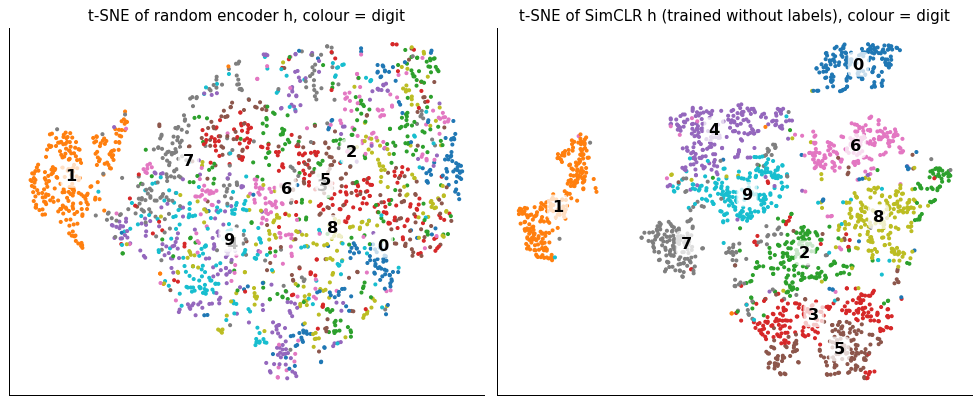

In [13]:
@torch.no_grad()
def align_uniform(model, X, seed=0):
    # alignment and uniformity of the normalised outputs of model on two augmentations of X
    g = torch.Generator().manual_seed(seed); model.eval()
    a = F.normalize(model(augment(X, g).to(device)), dim=1).cpu(); b = F.normalize(model(augment(X, g).to(device)), dim=1).cpu()
    align = (a - b).pow(2).sum(1).mean().item()
    unif = torch.pdist(a).pow(2).mul(-2).exp().mean().log().item()
    return align, unif

X_geo = X_test[:2000]
geo = {"random encoder (z)": align_uniform(nn.Sequential(enc_rand, projection_head().to(device)), X_geo),
       "SimCLR (z)": align_uniform(nn.Sequential(enc_ssl, head_ssl), X_geo),
       "SimCLR (h)": align_uniform(enc_ssl, X_geo)}
for k_, (a_, u_) in geo.items():
    print(f"{k_:20s}  alignment {a_:.3f}   uniformity {u_:.3f}")
print("reference: all points equal -> alignment 0, uniformity 0;  uniform on the sphere of R^64 -> uniformity about",
      round(math.log(np.mean(np.exp(-2 * torch.pdist(F.normalize(torch.randn(2000, 64), dim=1)).pow(2).numpy()))), 3))

t0 = time.time()
emb_rand = TSNE(2, perplexity=30, init="pca", learning_rate="auto", random_state=0).fit_transform(H_rand_te[:2000].numpy())
emb_ssl = TSNE(2, perplexity=30, init="pca", learning_rate="auto", random_state=0).fit_transform(H_ssl_te[:2000].numpy())
print(f"t-SNE of 2 x 2,000 points: {time.time() - t0:.0f} s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, emb, title in [(axes[0], emb_rand, "random encoder h"), (axes[1], emb_ssl, "SimCLR h (trained without labels)")]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y_test[:2000], cmap="tab10", s=5, vmin=-0.5, vmax=9.5)
    for c in range(10):
        cx, cy = np.median(emb[y_test[:2000].numpy() == c], axis=0)
        ax.text(cx, cy, str(c), fontsize=13, weight="bold", ha="center", va="center", bbox=dict(boxstyle="round", fc="white", alpha=0.75, lw=0))
    ax.set_title("t-SNE of " + title + ", colour = digit"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**What just happened?**
- The random network is collapsed by accident: alignment 0.002 (two views land at the same place) but uniformity $-0.005$, close to the worst value 0. All digits point in nearly the same direction, because $\mathbf{h}$ comes out of a ReLU and an average (all entries positive) and a random head maps it to almost one direction.
- SimCLR $\mathbf{z}$ has alignment 0.172 (positive pairs have cosine about $1 - 0.172/2 = 0.91$) and uniformity $-2.968$, on its way to the $-3.876$ of points spread uniformly over the sphere of $\mathbb{R}^{64}$. Training traded a little alignment for a lot of uniformity.
- $\mathbf{h}$ is much less uniform ($-0.306$): the loss shapes $\mathbf{z}$, not $\mathbf{h}$, and $\mathbf{h}$ is still a positive vector. It does not matter for the probe, which standardises the features first, nor for kNN, which centres them.
- The t-SNE maps show the same thing. With random weights only the 1s form a clear island; the other digits overlap in a large central mass. After SimCLR there are ten clusters, one per digit, found without a single label; the contacts that remain are between similar shapes, 4 with 9 and 3 with 5.

## 8. Collapse without negatives, and the SimSiam fix

Why do we need negatives? Drop them and keep only the positives: minimise $-\cos(\mathbf{z}, \mathbf{z}^+)$. A constant encoder, $f(x) = \mathbf{c}$ for every image, gives $\cos = 1$ for every pair: the **global minimum**, and useless. This is **complete collapse**. A milder failure is **dimensional collapse**: the embeddings vary only along a few directions of $\mathbb{R}^{64}$.

**SimSiam** (Chen and He, 2021) avoids collapse without negatives with two ingredients:

- a **predictor** $q$, a small MLP on top of one branch: $\mathbf{p} = q(\mathbf{z})$;
- a **stop-gradient** on the other branch, the target: $D(\mathbf{p}_1, \operatorname{sg}(\mathbf{z}_2))$, where $D$ is the negative cosine similarity. The loss is symmetrised: $\mathcal{L} = \tfrac12 D(\mathbf{p}_1, \operatorname{sg}(\mathbf{z}_2)) + \tfrac12 D(\mathbf{p}_2, \operatorname{sg}(\mathbf{z}_1))$.

Why this does not collapse is subtle. The constant solution is still a minimum of the loss; the stop-gradient changes the **dynamics**, not the objective. SimSiam's explanation: training alternates, like EM or $k$-means, between fitting the predictor to the current targets and moving the targets, and the predictor learns to anticipate the average over augmentations. BYOL (2020) uses the same idea with a target network that is a moving average of the online one.

We train two models for 300 steps with identical settings, **with** and **without** the stop-gradient, and track the standard deviation of the normalised projections over the batch (averaged over dimensions). For embeddings spread over the sphere of $\mathbb{R}^{64}$ it is about $1/\sqrt{64} = 0.125$; for a collapsed model it is 0.

In [14]:
class SimSiam(nn.Module):
    def __init__(self, stop_grad=True):
        super().__init__()
        self.stop_grad = stop_grad
        self.enc = Encoder()
        self.proj = projection_head()                                    # the same head as SimCLR: Linear-BN-ReLU-Linear
        self.pred = nn.Sequential(nn.Linear(64, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Linear(16, 64))   # bottleneck predictor q

    def loss(self, v1, v2):
        z1, z2 = self.proj(self.enc(v1)), self.proj(self.enc(v2))
        p1, p2 = self.pred(z1), self.pred(z2)
        t1, t2 = (z1.detach(), z2.detach()) if self.stop_grad else (z1, z2)          # sg(.)
        D = lambda p, z: -F.cosine_similarity(p, z, dim=1).mean()
        return 0.5 * D(p1, t2) + 0.5 * D(p2, t1), z1

def train_simsiam(stop_grad, steps=300, batch=256, lr=1e-3, seed=0, log_every=25):
    torch.manual_seed(seed); g = torch.Generator().manual_seed(seed)
    model = SimSiam(stop_grad).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    log = {"step": [], "loss": [], "zstd": []}; run = []
    for step in range(steps):
        model.train()
        x = X_unlab[torch.randint(0, n_unlab, (batch,), generator=g)]
        loss, z = model.loss(augment(x, g).to(device), augment(x, g).to(device))
        opt.zero_grad(); loss.backward(); opt.step()
        run.append((loss.item(), zstd(z)))
        if (step + 1) % log_every == 0:
            m = np.mean(run, axis=0); run = []
            log["step"].append(step + 1); log["loss"].append(m[0]); log["zstd"].append(m[1])
    return model, log

t0 = time.time()
siam, log_siam = train_simsiam(stop_grad=True)
nosg, log_nosg = train_simsiam(stop_grad=False)
print(f"two runs of 300 steps: {time.time() - t0:.0f} s")
for name, mdl, lg in [("SimSiam (stop-grad)", siam, log_siam), ("no stop-gradient", nosg, log_nosg)]:
    print(f"{name:20s} final loss {lg['loss'][-1]:+.4f}   std of normalised z {lg['zstd'][-1]:.4f}   kNN monitor {100 * knn_monitor(mdl.enc):.1f} %")
print(f"{'SimCLR (negatives)':20s} std of normalised z at step 300: {log_ssl['zstd'][5]:.4f}   kNN monitor at step 300: {100 * log_ssl['knn'][2]:.1f} %")
print("reference for a spread embedding: 1/sqrt(64) =", 1 / 8)

two runs of 300 steps: 37 s


SimSiam (stop-grad)  final loss -0.8069   std of normalised z 0.1029   kNN monitor 81.0 %


no stop-gradient     final loss -0.9975   std of normalised z 0.0082   kNN monitor 68.0 %
SimCLR (negatives)   std of normalised z at step 300: 0.1230   kNN monitor at step 300: 88.5 %
reference for a spread embedding: 1/sqrt(64) = 0.125


SimCLR z             spread along the first direction 0.3552, along the 10th 0.2180, total 4.126   effective rank 21.3 of 64
SimSiam z            spread along the first direction 0.4963, along the 10th 0.0728, total 2.947   effective rank 25.7 of 64
no stop-gradient z   spread along the first direction 0.0457, along the 10th 0.0055, total 0.224   effective rank 29.0 of 64


SimSiam (z)          alignment 0.385   uniformity -1.932
no stop-gradient (z) alignment 0.004   uniformity -0.018


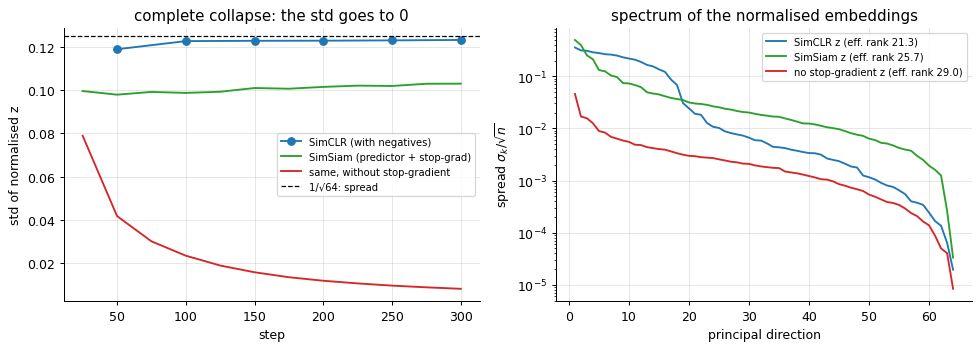

In [15]:
def spectrum(model, X):
    # singular values of the centred, normalised outputs (2,000 test images) / sqrt(n): the spread along each principal
    # direction; and the effective rank exp(entropy of the normalised singular values), between 1 and 64
    Z = F.normalize(features(model, X), dim=1); Z = Z - Z.mean(0)
    s = torch.linalg.svdvals(Z) / math.sqrt(len(Z)); p = s / s.sum()
    return s.numpy(), math.exp(-(p * torch.log(p + 1e-12)).sum().item())

spec = {"SimCLR z": spectrum(nn.Sequential(enc_ssl, head_ssl), X_geo),
        "SimSiam z": spectrum(nn.Sequential(siam.enc, siam.proj), X_geo),
        "no stop-gradient z": spectrum(nn.Sequential(nosg.enc, nosg.proj), X_geo)}
for k_, (p_, r_) in spec.items():
    print(f"{k_:20s} spread along the first direction {p_[0]:.4f}, along the 10th {p_[9]:.4f}, total {p_.sum():.3f}   effective rank {r_:4.1f} of 64")
geo["no stop-gradient (z)"] = align_uniform(nn.Sequential(nosg.enc, nosg.proj), X_geo)
geo["SimSiam (z)"] = align_uniform(nn.Sequential(siam.enc, siam.proj), X_geo)
for k_ in ["SimSiam (z)", "no stop-gradient (z)"]:
    print(f"{k_:20s} alignment {geo[k_][0]:.3f}   uniformity {geo[k_][1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log_ssl["step"][:6], log_ssl["zstd"][:6], "o-", color="C0", label="SimCLR (with negatives)")
axes[0].plot(log_siam["step"], log_siam["zstd"], color="C2", label="SimSiam (predictor + stop-grad)")
axes[0].plot(log_nosg["step"], log_nosg["zstd"], color="C3", label="same, without stop-gradient")
axes[0].axhline(1 / 8, color="k", ls="--", lw=1, label="1/√64: spread")
axes[0].set_xlabel("step"); axes[0].set_ylabel("std of normalised z"); axes[0].set_title("complete collapse: the std goes to 0"); axes[0].legend(fontsize=8)
for (k_, (p_, r_)), c in zip(spec.items(), ["C0", "C2", "C3"]):
    axes[1].semilogy(np.arange(1, 65), p_, color=c, label=f"{k_} (eff. rank {r_:.1f})")
axes[1].set_xlabel("principal direction"); axes[1].set_ylabel(r"spread $\sigma_k / \sqrt{n}$"); axes[1].set_title("spectrum of the normalised embeddings"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?**
- Without the stop-gradient the loss goes to $-0.9975$, almost the perfect $-1$, and the spread of the normalised projections falls from 0.079 (first 25 steps) to 0.008: every digit is sent to nearly the same point. The kNN monitor drops to 68.0 %, below the 71.1 % of the untrained network, and it would keep falling with more steps.
- With the stop-gradient, SimSiam keeps a spread of 0.103, close to the 0.125 of a uniform spread, and reaches 81.0 % kNN after 300 steps without a single negative. SimCLR is at 88.5 % at the same step: SimSiam starts more slowly.
- **The loss is misleading**: the collapsed model has the better loss ($-0.998$ against $-0.807$ for SimSiam). A low self-supervised loss does not mean good features; monitor the spread and a small kNN set.
- The spectra show both kinds of collapse. SimCLR spreads its embeddings over many directions: the 10th principal direction still has a spread of 0.218, against 0.355 for the first. SimSiam leans on its first direction (0.496, and 0.073 for the 10th): a mild **dimensional collapse**. Without the stop-gradient everything shrinks: a total spread of 0.224 against 4.126 for SimCLR, the **complete collapse**. The effective rank printed above (21.3, 25.7, 29.0) only measures the *shape* of the spectrum, not its scale, so it cannot see a complete collapse: always look at the scale too.
- Alignment and uniformity place the collapsed model in the "everything at one point" corner: 0.004 and $-0.018$. SimSiam: 0.385 and $-1.932$.

## 9. Ablation: the augmentations decide what is learned

If the views differ only in brightness and a missing patch, the network can tell positives apart by the exact position and size of the strokes; it never has to learn that a shifted or rotated "4" is still a "4". If the views differ only in crop and angle, it never has to cope with faded strokes or occlusions. We retrain SimCLR for 300 steps with three augmentation sets and compare with kNN on all 60,000 training digits and with a linear probe on $m = 10$ labels per class (3 draws). The full set at 300 steps is the snapshot saved during the main run (same seed, same views).

| run | crop + rotation | jitter | erasing |
|---|---|---|---|
| full $\mathcal{T}$ | yes | yes | yes |
| no crop / rotation | no | yes | yes |
| crop + rotation only | yes | no | no |

full T                 kNN 95.0 %   probe m = 10: 89.0 %   contrastive accuracy at step 300: 0.464


no crop / rotation     kNN 93.1 %   probe m = 10: 83.2 %   contrastive accuracy at step 300: 0.937


crop + rotation only   kNN 94.5 %   probe m = 10: 89.6 %   contrastive accuracy at step 300: 0.783
(64 s)


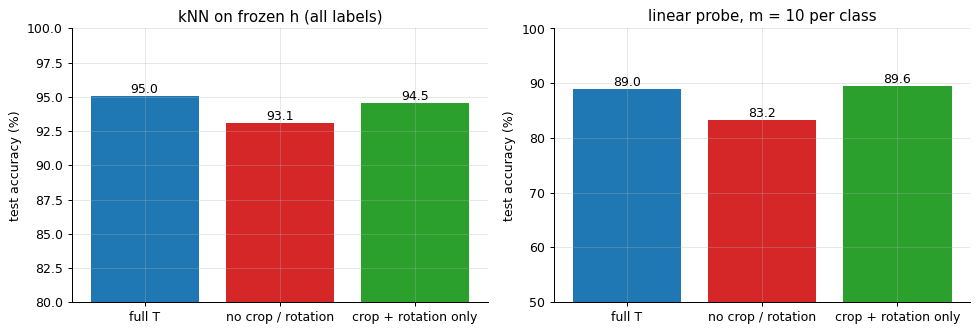

In [16]:
t0 = time.time()
enc_nogeo, _, log_nogeo, _ = train_simclr(300, aug=dict(geometric=False))
enc_geoonly, _, log_geoonly, _ = train_simclr(300, aug=dict(jitter=False, erase=False))
abl = {}
for name, e_, lg in [("full T", enc_300, None), ("no crop / rotation", enc_nogeo, log_nogeo), ("crop + rotation only", enc_geoonly, log_geoonly)]:
    Htr, Hte = features(e_, X_unlab), features(e_, X_test)
    knn_ = knn_accuracy(Htr, y_train, Hte, y_test)
    pr10 = np.mean([linear_probe(Htr[few_label_indices(10, s)], y_train[few_label_indices(10, s)], Hte, y_test) for s in range(3)])
    acc_end = log_ssl["acc"][5] if lg is None else lg["acc"][-1]
    abl[name] = (knn_, pr10, acc_end)
    print(f"{name:22s} kNN {100 * knn_:.1f} %   probe m = 10: {100 * pr10:.1f} %   contrastive accuracy at step 300: {acc_end:.3f}")
print(f"({time.time() - t0:.0f} s)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
nm = list(abl); cols = ["C0", "C3", "C2"]
for ax, j, title in [(axes[0], 0, "kNN on frozen h (all labels)"), (axes[1], 1, "linear probe, m = 10 per class")]:
    bars = ax.bar(nm, [100 * abl[n][j] for n in nm], color=cols); ax.bar_label(bars, fmt="%.1f")
    ax.set_ylim(50 if j else 80, 100); ax.set_title(title); ax.set_ylabel("test accuracy (%)")
plt.tight_layout(); plt.show()

**What just happened?**
- Removing crop and rotation hurts most: kNN 93.1 % instead of 95.0 %, and the 10-label probe 83.2 % instead of 89.0 %. Yet this run has the highest contrastive accuracy, 0.937: without geometric changes the two views are aligned pixel by pixel, so the network can match them by the exact position of the strokes. **An easy pretext task gives weak features.** For kNN, the ranking by contrastive accuracy (0.937, 0.783, 0.464) is exactly the reverse of the ranking by feature quality.
- Crop + rotation alone does as well as the full set at this budget (kNN 94.5 %, probe 89.6 %, against 95.0 % and 89.0 %). On digits, invariance to position, scale and angle is what matters; brightness jitter and erasing add little in 300 steps. On photos the colour distortion is essential, as SimCLR found, because two crops of a photo can otherwise be matched by their colours.

In [17]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 6.4 min on cpu


## 10. Summary

- **Self-supervision**: a pretext task whose targets come from the data (word2vec, BERT, GPT, autoencoders, rotation, inpainting). Protocol: pretrain on unlabelled data, then a linear probe, kNN or fine-tuning with few labels, compared with training from scratch on the same labels.
- **Contrastive learning (SimCLR)**: two augmentations of each image are positives, the other $2N - 2$ views of the batch are negatives; the encoder $f$ gives $\mathbf{h}$, the head $g$ gives $\mathbf{z}$, and the loss sees the cosine similarities $s_{ij}$.
- **NT-Xent / InfoNCE**: $\ell_i = -\log\big(e^{s_{i,p(i)}/\tau} / \sum_{k \ne i} e^{s_{ik}/\tau}\big)$, a softmax cross-entropy over the batch, with gradient $(P_{ik} - [k = p(i)])/\tau$. Toy batch: $\mathcal{L} = 1.2836$ (chance $\log 7 = 1.946$).
- **Temperature**: the pushes on two negatives are in the ratio $e^{(s_{ik} - s_{ik'})/\tau}$: 5.1 at $\tau = 0.5$ and 3,379 at $\tau = 0.1$ in the toy batch.
- **Lab, 60,000 unlabelled digits, 1,200 steps**: contrastive accuracy 0.58, kNN monitor 71.1 % → 91.3 %. Linear probe with all labels: SimCLR $\mathbf{h}$ 98.12 %, $\mathbf{z}$ 97.34 %, raw pixels 92.10 %, random encoder 90.46 %. Probe $\mathbf{h}$, not $\mathbf{z}$.
- **Few labels**: with 10 labels per class the probe on SimCLR features gets 92.5 %, training from scratch 88.0 %, pixels 73.2 %; the gap shrinks to about one point with 100 or 1,000 labels per class.
- **Geometry**: alignment $\mathbb{E}\lVert\hat{\mathbf{z}} - \hat{\mathbf{z}}^+\rVert^2$ and uniformity $\log\mathbb{E}\,e^{-2\lVert\hat{\mathbf{z}}_x - \hat{\mathbf{z}}_y\rVert^2}$: SimCLR 0.172 and $-2.968$; a random network 0.002 and $-0.005$ (every digit in nearly one direction).
- **Collapse**: without negatives a constant encoder is a minimum. SimSiam's predictor and stop-gradient keep the spread (0.103, kNN 81.0 % after 300 steps); without the stop-gradient the spread falls to 0.008 while the loss reaches $-0.9975$. A low self-supervised loss does not mean good features.
- **Augmentations define the invariances**: without crop and rotation the 10-label probe falls from 89.0 % to 83.2 %, while the pretext task gets easier (contrastive accuracy 0.937).

## Exercises

Try each one before opening the answer.

1. **Temperature limits.** Show that $\tau\,\ell_i \to \max\big(0,\ \max_{k \notin \{i, p(i)\}} s_{ik} - s_{i,p(i)}\big)$ as $\tau \to 0$, and that $\ell_i \approx \log(2N-1) - (s_{i,p(i)} - \bar s_i)/\tau$ for large $\tau$, where $\bar s_i$ is the mean similarity of view $i$ to its $2N-1$ candidates. What does each limit say about the negatives?
2. **Gradient on the embeddings.** With unit vectors $\hat{\mathbf{z}}$ and $s_{ik} = \hat{\mathbf{z}}_i^\top\hat{\mathbf{z}}_k$, compute $\partial\ell_i/\partial\hat{\mathbf{z}}_i$ and describe the direction in which a gradient step moves $\hat{\mathbf{z}}_i$.
3. **The mutual-information bound.** InfoNCE gives $I(\tilde x; \tilde x') \ge \log(2N - 1) - \mathcal{L}$. What is the largest value this bound can certify with $N = 256$, and what does the final loss of section 4 give? Why does this argue for large batches?
4. **False negatives.** In a batch of $N = 256$ MNIST images, how many of the negatives of a view are, on average, views of an image of the same digit? Why does contrastive learning work anyway, and how could labels be used to fix it?
5. **Collapse.** Show that a constant encoder minimises the positives-only loss $-\cos(\mathbf{z}, \mathbf{z}^+)$. What is the NT-Xent loss of a constant encoder with $N = 256$? Is it a minimum?
6. **Fashion-MNIST.** Replace MNIST by `torchvision.datasets.FashionMNIST` (and `MEAN, STD = 0.2860, 0.3530`) and re-run sections 4 to 6. Compare the 10-label probe on SimCLR features with logistic regression on pixels. What could make clothes harder than digits for this setup, and what would you change?

<details>
<summary><b>Answers</b></summary>

**1.** $\tau\ell_i = -s_{i,p(i)} + \tau\log\sum_{k \ne i} e^{s_{ik}/\tau}$. The log-sum-exp is a soft maximum: $\max_k s_{ik} \le \tau\log\sum_k e^{s_{ik}/\tau} \le \max_k s_{ik} + \tau\log(2N-1)$, so as $\tau \to 0$ it tends to $\max_{k \ne i} s_{ik}$, and $\tau\ell_i \to \max_{k\ne i} s_{ik} - s_{i,p(i)} = \max\big(0, \max_{k \notin\{i,p(i)\}} s_{ik} - s_{i,p(i)}\big)$: a hinge that looks only at the **hardest negative** and is zero once the positive is the most similar candidate. For large $\tau$, $e^{s/\tau} \approx 1 + s/\tau$, so $\log\sum_k e^{s_{ik}/\tau} \approx \log(2N-1) + \bar s_i/\tau$ and $\ell_i \approx \log(2N-1) - (s_{i,p(i)} - \bar s_i)/\tau$: **every negative counts the same**, through the mean, and the loss stays close to its chance value. In section 2: $\ell_{1a} = 0.061$ at $\tau = 0.05$ and $1.707$ at $\tau = 2$, against $\log 7 = 1.946$.

**2.** $\partial\ell_i/\partial\hat{\mathbf{z}}_i = \sum_{k \ne i}\frac{\partial \ell_i}{\partial s_{ik}}\hat{\mathbf{z}}_k = \frac{1}{\tau}\Big(\sum_{k \ne i} P_{ik}\hat{\mathbf{z}}_k - \hat{\mathbf{z}}_{p(i)}\Big)$. A gradient step $-\eta\,\partial\ell_i/\partial\hat{\mathbf{z}}_i$ moves $\hat{\mathbf{z}}_i$ **towards its positive** and **away from the $P$-weighted mean of all candidates**, dominated by the hard negatives. The full gradient adds the terms from the rows where $i$ is a candidate, and the normalisation $\mathbf{z}/\lVert\mathbf{z}\rVert$ keeps only the component tangent to the sphere.

**3.** The bound can never exceed $\log(2N-1) = \log 511 = 6.236$ nats, whatever the loss. With the final loss of section 4, $I \ge 6.236 - 4.578 = 1.66$ nats. A larger batch raises the ceiling $\log(2N-1)$, gives more hard negatives and a less noisy estimate of the denominator; this is why SimCLR uses $N = 4{,}096$ and MoCo a queue of 65,536 keys.

**4.** Each view has $2(N-1) = 510$ negatives; about a tenth of the other 255 images show the same digit, about 25.5 images, so about **51 of the 510 negatives** are false negatives. It works anyway because the push on a negative is weighted by its probability $P_{ik}$ and spread over hundreds of negatives, while the single positive is pulled with weight $(1 - P_{i,p(i)})/\tau$; and the encoder cannot separate two 4s much without also separating views of one 4. With labels, **supervised contrastive learning** (SupCon, Khosla et al., 2020) treats all images of the same class as positives.

**5.** If $f(x) = \mathbf{c}$ for every image, then $\mathbf{z} = g(\mathbf{c})$ is the same for both views and $-\cos(\mathbf{z}, \mathbf{z}^+) = -1$, the smallest possible value: a global minimum that carries no information. For NT-Xent, a constant encoder makes every $s_{ik} = 1$, so $P_{ik} = 1/(2N-1)$ and $\ell_i = \log(2N-1) = \log 511 = 6.236$: exactly the chance value, the **opposite** of a minimum. The negatives in the denominator are what rule the constant solution out. Section 8 shows the positives-only collapse in practice: loss $-0.9975$, spread 0.008.

**6.** In our quick tests with this encoder and a few minutes of pretraining, the 10-label probe on SimCLR features reached about 67 to 69 %, no better than logistic regression on the pixels (67 %); the advantage seen on MNIST disappears. Clothes classes differ by texture and by details inside similar silhouettes (shirt, T-shirt, pullover, coat), the pixel intensities already encode the silhouette, and a 23,520-parameter encoder pretrained for a few minutes learns mostly coarse shape. Things to try: a wider and deeper encoder, many more steps (SSL papers train for hundreds of epochs), horizontal flips (harmless for clothes, unlike digits), milder crops, and a temperature sweep. The lesson is general: self-supervision needs enough compute and the right invariances for the domain.

</details>